In [1]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import clip

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA



In [2]:

# Config
DATA_DIR = Path("data/raw")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

# ----------------------------
# Load file paths
# ----------------------------
def get_image_paths(class_dir: Path):
    paths = []
    for p in class_dir.rglob("*"):
        if p.suffix.lower() in IMAGE_EXTS:
            paths.append(p)
    return sorted(paths)

tig_paths = get_image_paths(DATA_DIR / "tig")
buster_paths = get_image_paths(DATA_DIR / "buster")

if len(tig_paths) == 0 or len(buster_paths) == 0:
    raise ValueError(
        "Need images in both data/raw/tig and data/raw/buster before running."
    )

all_paths = tig_paths + buster_paths
labels = np.array([0] * len(tig_paths) + [1] * len(buster_paths))
label_names = {0: "tig", 1: "buster"}

print(f"Tig images: {len(tig_paths)}")
print(f"Buster images: {len(buster_paths)}")
print(f"Total images: {len(all_paths)}")
print(f"Using device: {DEVICE}")


Tig images: 20
Buster images: 20
Total images: 40
Using device: cuda


In [3]:

# Load CLIP
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model.eval()

# ----------------------------
# Encode images
# ----------------------------
def load_image(path: Path):
    img = Image.open(path).convert("RGB")
    return clip_preprocess(img)

def encode_images(paths, batch_size=32):
    features = []
    valid_paths = []

    for i in tqdm(range(0, len(paths), batch_size), desc="Encoding images"):
        batch_paths = paths[i:i+batch_size]
        batch_tensors = []
        for p in batch_paths:
            try:
                batch_tensors.append(load_image(p))
                valid_paths.append(p)
            except Exception as e:
                print(f"Skipping {p}: {e}")

        if not batch_tensors:
            continue

        batch = torch.stack(batch_tensors).to(DEVICE)
        with torch.no_grad():
            feats = clip_model.encode_image(batch)
            feats = feats / feats.norm(dim=-1, keepdim=True)
        features.append(feats.cpu().numpy())

    if not features:
        raise ValueError("No valid images could be encoded.")

    return np.vstack(features), valid_paths

X, valid_paths = encode_images(all_paths, batch_size=BATCH_SIZE)

# If any images failed, realign labels
path_to_label = {str(p): y for p, y in zip(all_paths, labels)}
y = np.array([path_to_label[str(p)] for p in valid_paths])

print(f"Encoded feature matrix shape: {X.shape}")

# ----------------------------
# Train / validation split
# ----------------------------
X_train, X_val, y_train, y_val, paths_train, paths_val = train_test_split(
    X, y, valid_paths,
    test_size=0.25,
    stratify=y,
    random_state=SEED
)

print(f"Train size: {len(y_train)}")
print(f"Validation size: {len(y_val)}")

# Baseline 1: Logistic regression
# ----------------------------
clf = LogisticRegression(max_iter=5000, random_state=SEED)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)

acc = accuracy_score(y_val, y_pred)
print(f"\nValidation accuracy: {acc:.3f}\n")
print(classification_report(y_val, y_pred, target_names=["tig", "buster"]))


Encoding images: 100%|██████████| 2/2 [00:02<00:00,  1.45s/it]

Encoded feature matrix shape: (40, 512)
Train size: 30
Validation size: 10

Validation accuracy: 1.000

              precision    recall  f1-score   support

         tig       1.00      1.00      1.00         5
      buster       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



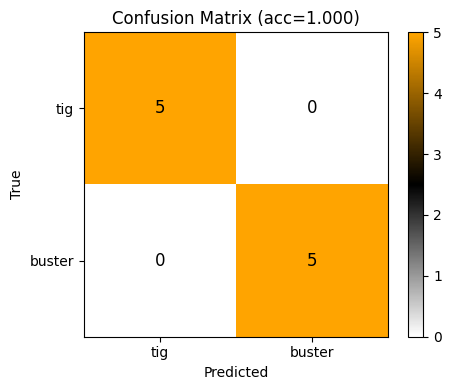

In [4]:
# ----------------------------
# Confusion matrix plot
# ----------------------------
from matplotlib.colors import LinearSegmentedColormap

# Custom colormap: orange -> black -> white
colors = [(1.0, 0.647, 0.0), (0, 0, 0), (1, 1, 1)]  # orange, black, white
custom_cmap = LinearSegmentedColormap.from_list("custom_tig_buster", colors, N=256)

cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap=custom_cmap.reversed())
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["tig", "buster"])
ax.set_yticklabels(["tig", "buster"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix (acc={acc:.3f})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_gradient.png", dpi=200)
plt.show()

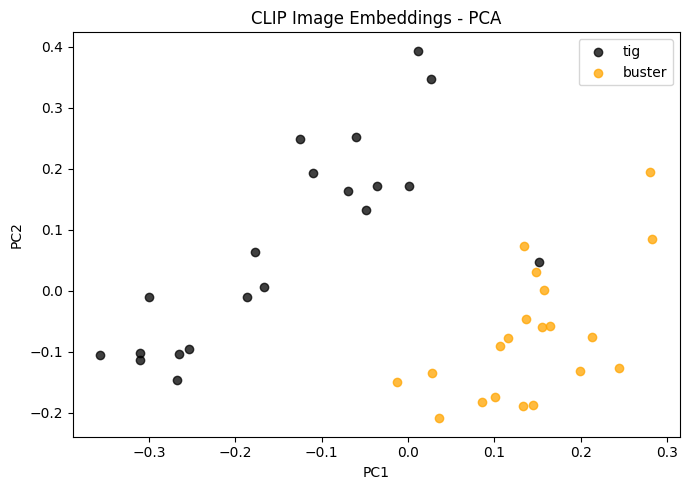

In [5]:
# ----------------------------
# PCA plot of embeddings
# ----------------------------
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 5))
for cls in [0, 1]:
    idx = y == cls
    color = 'black' if cls == 0 else 'orange'
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
               color=color,
               label=label_names[cls],
               alpha=0.75)

ax.set_title("CLIP Image Embeddings - PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "embedding_pca.png", dpi=200)
plt.show()

In [6]:

# ----------------------------
# Save example mistakes
# ----------------------------
mistakes = []
for p, true_y, pred_y in zip(paths_val, y_val, y_pred):
    if true_y != pred_y:
        mistakes.append((p, true_y, pred_y))

with open(OUTPUT_DIR / "mistakes.txt", "w") as f:
    for p, true_y, pred_y in mistakes:
        f.write(f"{p} | true={label_names[true_y]} | pred={label_names[pred_y]}\n")

# ----------------------------
# Save simple summary
# ----------------------------
with open(OUTPUT_DIR / "summary.txt", "w") as f:
    f.write(f"Tig images: {len(tig_paths)}\n")
    f.write(f"Buster images: {len(buster_paths)}\n")
    f.write(f"Total valid encoded images: {len(y)}\n")
    f.write(f"Train size: {len(y_train)}\n")
    f.write(f"Validation size: {len(y_val)}\n")
    f.write(f"Validation accuracy: {acc:.4f}\n")
    f.write(f"PCA variance explained: {pca.explained_variance_ratio_}\n")
    f.write(f"Number of mistakes: {len(mistakes)}\n")

print("\nDone.")
print("Saved:")
print(" - outputs/confusion_matrix.png")
print(" - outputs/embedding_pca.png")
print(" - outputs/mistakes.txt")
print(" - outputs/summary.txt")


Done.
Saved:
 - outputs/confusion_matrix.png
 - outputs/embedding_pca.png
 - outputs/mistakes.txt
 - outputs/summary.txt


In [7]:
clf = LogisticRegression(max_iter=5000, random_state=SEED)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)

acc = accuracy_score(y_val, y_pred)
print(f"\nValidation accuracy: {acc:.3f}\n")
print(classification_report(y_val, y_pred, target_names=["tig", "buster"]))


Validation accuracy: 1.000

              precision    recall  f1-score   support

         tig       1.00      1.00      1.00         5
      buster       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



Repeated CV mean accuracy: 0.975
Repeated CV std: 0.049999999999999996


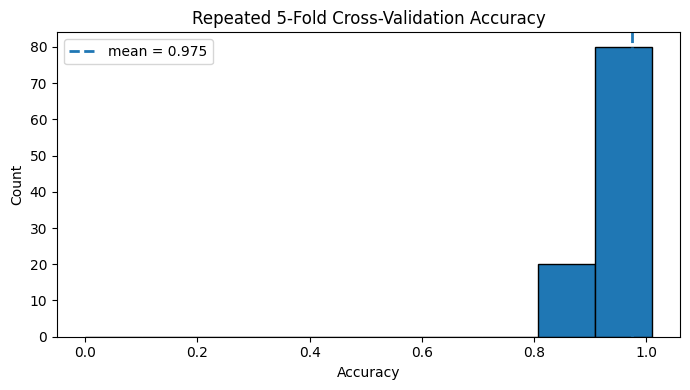

In [9]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

# ----------------------------
# Better accuracy figure: repeated CV
# ----------------------------
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=SEED)

cv_scores = cross_val_score(
    LogisticRegression(max_iter=5000, random_state=SEED),
    X, y,
    cv=cv,
    scoring="accuracy"
)

cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print("Repeated CV mean accuracy:", cv_mean)
print("Repeated CV std:", cv_std)

fig, ax = plt.subplots(figsize=(7, 4))

bins = np.linspace(0, 1.01, 11)
ax.hist(cv_scores, bins=bins, edgecolor="black")
ax.axvline(cv_mean, linestyle="--", linewidth=2, label=f"mean = {cv_mean:.3f}")
ax.set_xlabel("Accuracy")
ax.set_ylabel("Count")
ax.set_title("Repeated 5-Fold Cross-Validation Accuracy")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "repeated_cv_accuracy_hist.png", dpi=200)
plt.show()

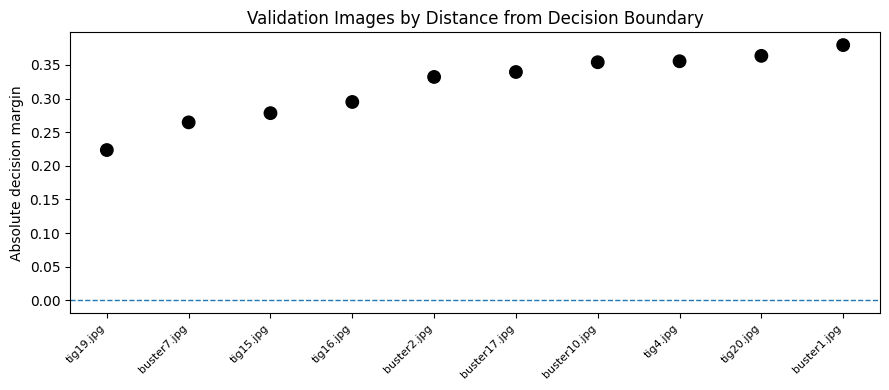

In [10]:
# ----------------------------
# Better confidence figure: decision margins
# ----------------------------
val_margin = clf.decision_function(X_val)

margin_df = pd.DataFrame({
    "image": [p.name for p in paths_val],
    "true_label": [label_names[v] for v in y_val],
    "pred_label": [label_names[v] for v in y_pred],
    "margin": val_margin
})

# absolute distance from decision boundary
margin_df["abs_margin"] = np.abs(margin_df["margin"])
margin_df["correct"] = margin_df["true_label"] == margin_df["pred_label"]
margin_df = margin_df.sort_values("abs_margin")

fig, ax = plt.subplots(figsize=(9, 4))

colors = ["black" if c else "red" for c in margin_df["correct"]]
ax.scatter(range(len(margin_df)), margin_df["abs_margin"], s=80, c=colors)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(range(len(margin_df)))
ax.set_xticklabels(margin_df["image"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Absolute decision margin")
ax.set_title("Validation Images by Distance from Decision Boundary")

for i, row in enumerate(margin_df.itertuples()):
    if not row.correct:
        ax.annotate("mistake", (i, row.abs_margin), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_margin_plot.png", dpi=200)
plt.show()

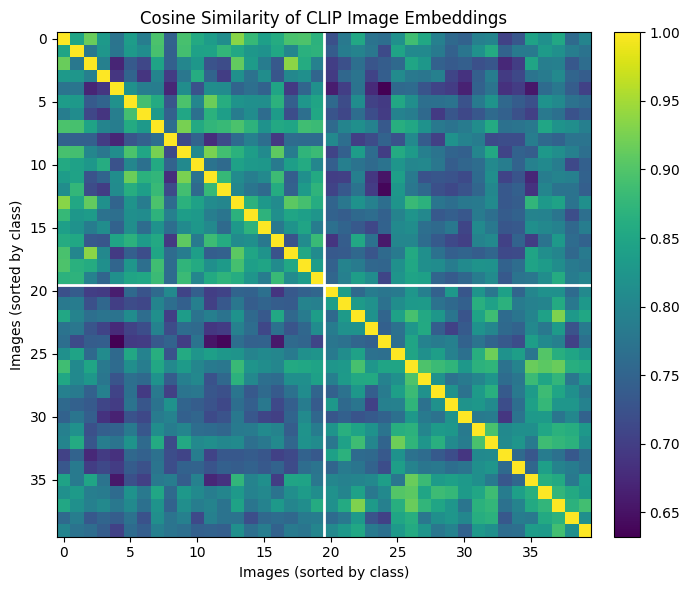

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

# ----------------------------
# Representation figure: similarity heatmap
# ----------------------------
sim = cosine_similarity(X)

# sort images by label, then by first PCA coordinate if available
order = np.argsort(y)
sim_sorted = sim[order][:, order]
y_sorted = y[order]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_sorted, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# draw boundary between classes
boundary = np.sum(y_sorted == 0)
ax.axhline(boundary - 0.5, color="white", linewidth=2)
ax.axvline(boundary - 0.5, color="white", linewidth=2)

ax.set_title("Cosine Similarity of CLIP Image Embeddings")
ax.set_xlabel("Images (sorted by class)")
ax.set_ylabel("Images (sorted by class)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "embedding_similarity_heatmap.png", dpi=200)
plt.show()